In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
data = pd.read_csv("FinalBalancedDataset.csv")

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56745 entries, 0 to 56744
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  56745 non-null  int64 
 1   Toxicity    56745 non-null  int64 
 2   tweet       56745 non-null  object
dtypes: int64(2), object(1)
memory usage: 1.3+ MB


In [6]:
data.head(5)

,Unnamed: 0,Toxicity,tweet
0,0,0,@user when a father is dysfunctional and is s...
1,1,0,@user @user thanks for #lyft credit i can't us...
2,2,0,bihday your majesty
3,3,0,#model i love u take with u all the time in ...
4,4,0,factsguide: society now #motivation


In [7]:
data = data.drop("Unnamed: 0", axis=1)

In [8]:
data.head(5)

,Toxicity,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [9]:
data['Toxicity'].value_counts()

,count
Toxicity,
0,32592
1,24153


In [15]:
import nltk
nltk.download('punkt_tab')
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
from nltk import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords as nltk_stopwords
from nltk.corpus import wordnet

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## Lemmatizer
Leaves<br>
Leafs<br>Leaf

## Text pre-processing

In [11]:
wordnet_lemmatizer = WordNetLemmatizer()

In [12]:
import re

In [13]:
def prepare_text(text):
    def get_wordnet_pos(treebank_tag):
        if treebank_tag.startswith('J'):
            return wordnet.ADJ
        elif treebank_tag.startswith('V'):
            return wordnet.VERB
        elif treebank_tag.startswith('N'):
            return wordnet.NOUN
        elif treebank_tag.startswith('R'):
            return wordnet.ADV
        else:
            return wordnet.NOUN
    text = re.sub(r'[^a-zA-Z\']', ' ', text)
    text = text.split()
    text = ' '.join(text)
    text = word_tokenize(text)
    text = pos_tag(text)
    lemma = []
    for i in text: lemma.append(wordnet_lemmatizer.lemmatize(i[0], pos = get_wordnet_pos(i[1])))
    lemma = ' '.join(lemma)
    return lemma

In [16]:
data['clean_tweets'] = data['tweet'].apply(lambda x: prepare_text(x))

In [17]:
data.head(5)

,Toxicity,tweet,clean_tweets
0,0,@user when a father is dysfunctional and is s...,user when a father be dysfunctional and be so ...
1,0,@user @user thanks for #lyft credit i can't us...,user user thanks for lyft credit i ca n't use ...
2,0,bihday your majesty,bihday your majesty
3,0,#model i love u take with u all the time in ...,model i love u take with u all the time in ur
4,0,factsguide: society now #motivation,factsguide society now motivation


## Tf-Idf for Features

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [19]:
corpus = data['clean_tweets'].values.astype('U')

In [21]:
stopwords = list(nltk_stopwords.words('english'))

In [22]:
count_tf_idf = TfidfVectorizer(stop_words = stopwords)
tf_idf = count_tf_idf.fit_transform(corpus)

In [23]:
import pickle

In [24]:
pickle.dump(count_tf_idf, open("tf_idf.pkt", "wb"))

In [26]:
tf_idf_train, tf_idf_test, target_train, target_test = train_test_split(
    tf_idf, data['Toxicity'], test_size = 0.2, random_state= 42, shuffle=True
)

## Create a Binary Classification Model

In [27]:
model_bayes = MultinomialNB()

In [28]:
model_bayes = model_bayes.fit(tf_idf_train, target_train)

In [29]:
y_pred_proba = model_bayes.predict_proba(tf_idf_test)[::, 1]

In [30]:
y_pred_proba

array([0.92939957, 0.33114694, 0.93027118, ..., 0.65072285, 0.02482516,
       0.93410274])

In [31]:
fpr, tpr, _ = roc_curve(target_test, y_pred_proba)

In [32]:
final_roc_auc = roc_auc_score(target_test, y_pred_proba)

In [36]:
print(f'ROC AUC Score: {final_roc_auc}')

ROC AUC Score: 0.9706848896956604


# Plot ROC Curve

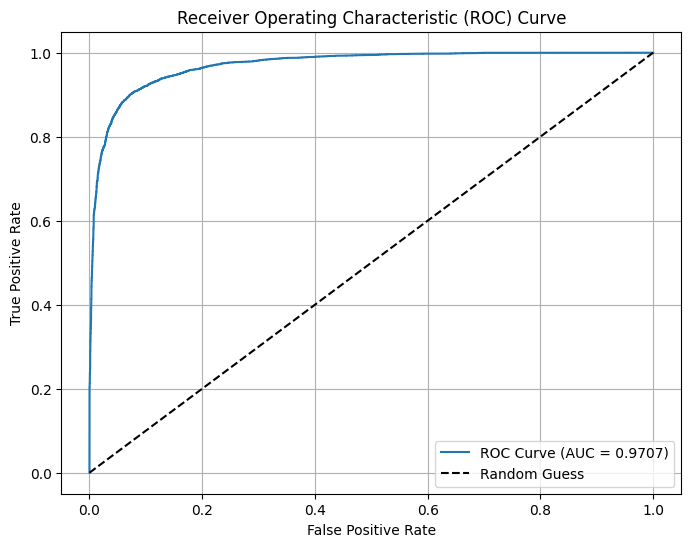

In [37]:

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {final_roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Predict on a New Sample Text

In [39]:
test_text = "I hate you moron"
print(f"\nPredicting toxicity for the sample text: '{test_text}'")
processed_test_text = prepare_text(test_text)
test_tfidf = count_tf_idf.transform([processed_test_text])
pred_proba = model_bayes.predict_proba(test_tfidf)
pred_label = model_bayes.predict(test_tfidf)
print(f"Prediction Probabilities: {pred_proba}")
print(f"Predicted Label: {pred_label[0]}")  # 0 for non-toxic, 1 for toxic


Predicting toxicity for the sample text: 'I hate you moron'
Prediction Probabilities: [[0.25224777 0.74775223]]
Predicted Label: 1


## Save the model

In [38]:
print("\nSaving the trained model to 'toxicity_model.pkt'...")
with open("toxicity_model.pkt", "wb") as f:
    pickle.dump(model_bayes, f)
print("Model saved successfully.")


Saving the trained model to 'toxicity_model.pkt'...
Model saved successfully.
